## Importando Bibliotecas

In [24]:
import pandas as pd
import numpy as np

from sklearn import linear_model
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

### Carregando dados

In [25]:
df = pd.read_csv('../../data/iris.csv')
df.head()

,comprimento_sepala,largura_sepala,comprimento_petala,largura_petala,Tipo_Orquidea
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


## Limpeza e Preparação

### Visão geral dos dados

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   comprimento_sepala  150 non-null    float64
 1   largura_sepala      150 non-null    float64
 2   comprimento_petala  150 non-null    float64
 3   largura_petala      150 non-null    float64
 4   Tipo_Orquidea       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


### Verificando a presença de valores duplicados ou faltantes

In [27]:
df.isna().sum()

comprimento_sepala    0
largura_sepala        0
comprimento_petala    0
largura_petala        0
Tipo_Orquidea         0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(1)

In [29]:
df.loc[df.duplicated(keep=False) == True]

,comprimento_sepala,largura_sepala,comprimento_petala,largura_petala,Tipo_Orquidea
101,5.8,2.7,5.1,1.9,0
142,5.8,2.7,5.1,1.9,0


removendo duplicata

In [30]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### Verificando se as medidas resumo fazem sentido

In [31]:
df.describe()

,comprimento_sepala,largura_sepala,comprimento_petala,largura_petala,Tipo_Orquidea
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,0.335570
std,0.830851,0.436342,1.767791,0.762622,0.473782
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.300000,1.300000,0.000000
75%,6.400000,3.300000,5.100000,1.800000,1.000000
max,7.900000,4.400000,6.900000,2.500000,1.000000


## Análise Exploratória

### Analisando a distribuição das *features* e como elas se relacionam com o *target*

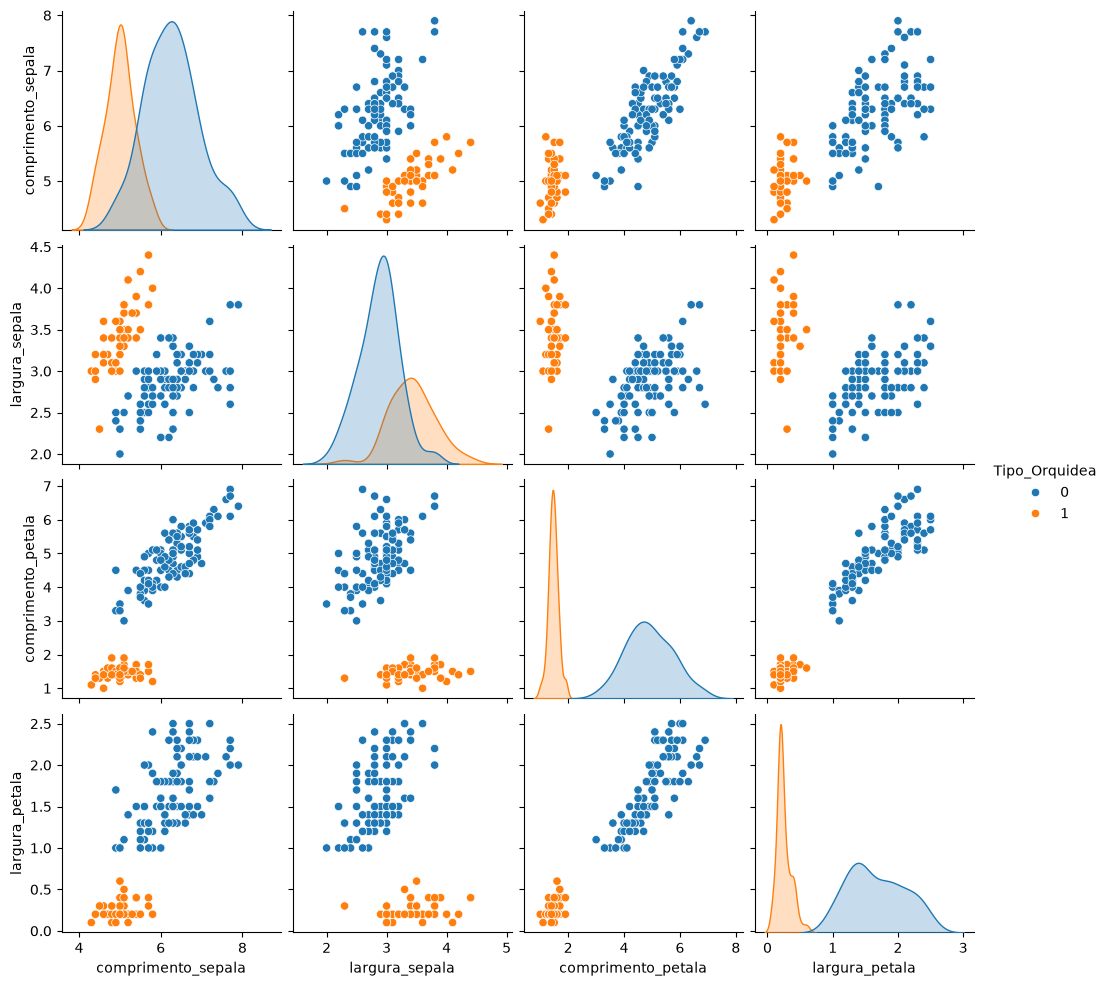

In [32]:
sns.pairplot(df, hue='Tipo_Orquidea')

### Verificando a correlação das variáveis entre si

<Axes: >

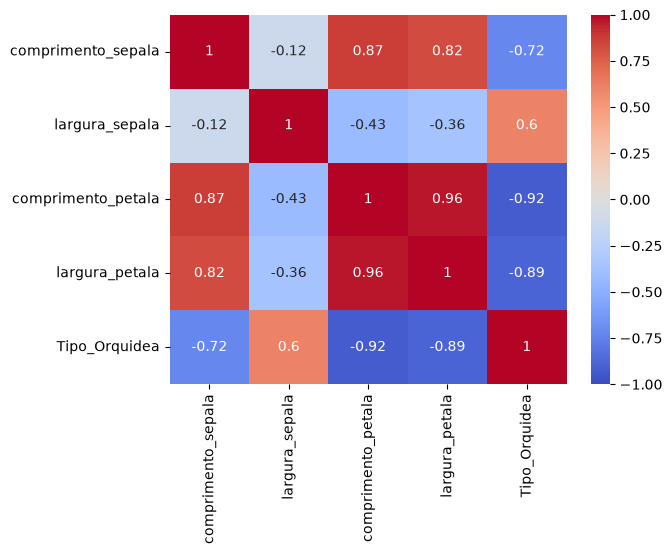

In [33]:
sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True, cmap='coolwarm')

as variáveis possuem forte correlação com o target e entre si mesmas. Pode haver certa multicolinearidade

## Treinando o modelo

In [34]:
y = df['Tipo_Orquidea']

x = df.drop(columns='Tipo_Orquidea')

In [35]:
modelo = linear_model.LogisticRegression(fit_intercept=True, random_state=42)

modelo.fit(x, y)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

In [36]:
print("Intercepto: {}" .format(modelo.intercept_))
print("Coeficientes: {}" .format(modelo.coef_))

Intercepto: [6.68795524]
Coeficientes: [[-0.44459769  0.89951624 -2.32076571 -0.98001264]]


### Criando a coluna "Y_Estimado" com um corte de probabilidade de 0.5

In [ ]:
# Calculo do z-score
z = 6.68795524 - 0.44459769 * df['comprimento_sepala'] + 0.89951624 * df['largura_sepala'] - 2.32076571 * df['comprimento_petala']  - 0.98001264 * df['largura_petala']

np.round(z, decimals=4)

0      4.1237
1      3.7629
2      4.2638
3      3.7542
4      4.2582
        ...  
145   -7.9143
146   -7.3301
147   -7.5314
148   -7.7964
149   -6.8366
Length: 149, dtype: float64

In [ ]:
# calculo da probabilidade de y = 1 ou g(z)
gz = 1/(1 + np.exp(-z))

np.round(gz, decimals=4)

0      0.9841
1      0.9773
2      0.9861
3      0.9771
4      0.9860
        ...  
145    0.0004
146    0.0007
147    0.0005
148    0.0004
149    0.0011
Length: 149, dtype: float64

In [46]:
# calculando o y estimado manualmente
y_estimado = np.where(gz >= 0.5 , 1 , 0)
y_estimado

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [47]:
# Calculando o y estimado utilizando os métodos do Scikit-Learn
modelo.predict(x)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Verificando a Acurácia

In [48]:
(y_estimado == y).sum()

np.int64(149)

In [49]:
len(y)

149

In [50]:
# calculando a acurácia manualmente
acuracia = (y_estimado == y).sum() / len(y)
acuracia

np.float64(1.0)

In [ ]:
# calculando a acurácia utilizando os métodos do Scikit-Learn
accuracy_score(y_estimado, y)

1.0

## Interpretando os Coeficientes do modelo

In [52]:
print("Intercepto: {}" .format(modelo.intercept_))
print("Coeficientes: {}" .format(modelo.coef_))

Intercepto: [6.68795524]
Coeficientes: [[-0.44459769  0.89951624 -2.32076571 -0.98001264]]


In [53]:
np.exp(modelo.intercept_)

array([802.67928856])

In [54]:
np.exp(modelo.coef_)

array([[0.64108214, 2.45841355, 0.09819837, 0.37530635]])

**Equação do Modelo**

Tipo Orquídea = $\beta_0$ + $\beta_1$ * Comprimento Sepala + $\beta_2$ * Largura Sepala + $\beta_3$ * Comprimento Petala + $\beta_4$ * Largura Petala
<br></br>

- $e^{\beta_0}$: Chance de uma flor com zero largura e comprimento da pétala e sépala pertencerem ao tipo 1 é de 805.
- $e^{\beta_1}$: Cada aumento de 1cm no comprimento da sepala diminui em 36% a chance da flor pertencer ao tipo 1, mantendo tudo o mais constante.
- $e^{\beta_2}$: Cada aumento de 1cm na largura da sepala aumenta em 146% a chance da flor pertencer ao tipo 1, mantendo tudo o mais constante.
- $e^{\beta_3}$: Cada aumento de 1cm no comprimento da pétala diminui em 90% a chance da flor pertencer ao tipo 1, mantendo tudo o mais constante.
- $e^{\beta_4}$: Cada aumento de 1cm na largura da pétala diminui em 62% a chance da flor pertencer ao tipo 1, mantendo tudo o mais constante.